# ASPset-510 — what is actually in this dataset

A guided tour of the copy of **ASPset-510** sitting in `ASPset/`. The goal is a working mental
picture of the data: what a "clip" is, what each file holds, how the pieces line up, and what the
limitations are — before you build anything on top of it.

ASPset-510 is an **outdoor sports 3D human pose** dataset ([Nibali et al.,
2021](https://github.com/anibali/aspset-510)): athletes filmed by three fixed 4K cameras, with 3D
joint positions captured at the same time.

| Part | What it covers |
|---|---|
| 1 | The folder layout, and an inventory of what we have |
| 2 | One clip, all four of its files side by side |
| 3 | The 3D joints: names, units, and which way is up |
| 4 | The cameras: projecting 3D joints onto the video frame |
| 5 | The bounding boxes, and how small the subject really is |
| 6 | Dataset-wide statistics |
| 7 | Summary, gotchas, and how this maps onto MHR |

Everything here is measured from the files, not copied from documentation — this copy of the
dataset ships no README.

---
## Part 0 — Setup

In [1]:
import collections
import glob
import json
import pathlib
import warnings

import c3d                    # reader for the .c3d motion-capture format
import cv2                    # video decoding
import numpy as np
import matplotlib.pyplot as plt

# Run correctly whether the notebook sits in the repo root or in "demos ipynb/".
ROOT = pathlib.Path.cwd()
if not (ROOT / "ASPset").exists():
    ROOT = ROOT.parent

DATA = ROOT / "ASPset"
np.set_printoptions(precision=2, suppress=True)

# Every .c3d here stores pose only, and the reader says so on each file. Nothing to fix.
warnings.filterwarnings("ignore", message="No analog data found in file.")

print("dataset folder:", DATA)
print("top-level entries:")
for entry in sorted(DATA.iterdir()):
    if entry.is_dir():
        print("   ", entry.name)

dataset folder: /Users/rzt/Documents/mhr_env/ASPset
top-level entries:
    ASPset-510
    ASPset-510 2
    ASPset-510 3
    ASPset-510 4


### Why there are four look-alike folders

Those four folders are **not duplicates, and none of them is safe to delete.** ASPset-510 is
published as one archive per *modality*, and unzipping four archives that each contain a folder
called `ASPset-510` makes macOS number them. So each folder holds a different kind of file:

| folder | holds | one file per |
|---|---|---|
| `ASPset-510` | `videos/` — the 4K footage | clip |
| `ASPset-510 2` | `boxes/` — bounding boxes | clip |
| `ASPset-510 3` | `cameras/` — calibration | subject × camera |
| `ASPset-510 4` | `joints_3d/` — the 3D ground truth | clip |

The naming inside is regular, which is what lets us stitch them back together:

```
<modality>/<split>/<subject>/<subject>-<clip>-<view>.<ext>
```

with one exception worth remembering: **`joints_3d` files have no `-<view>` suffix**, because the
3D joints live in a single world frame shared by all three cameras rather than belonging to any
one of them.

In [2]:
# One path helper per modality. Keeping these in one place means the odd folder names
# appear exactly once in the notebook.
SPLIT = "train"

VIDEO_DIR = DATA / "ASPset-510" / SPLIT / "videos"
BOX_DIR = DATA / "ASPset-510 2" / SPLIT / "boxes"
CAMERA_DIR = DATA / "ASPset-510 3" / SPLIT / "cameras"
JOINTS_DIR = DATA / "ASPset-510 4" / SPLIT / "joints_3d"

for name, folder in [("videos", VIDEO_DIR), ("boxes", BOX_DIR),
                     ("cameras", CAMERA_DIR), ("joints_3d", JOINTS_DIR)]:
    files = sorted(folder.glob("*/*"))
    print(f"{name:<10} {len(files):>3} files   e.g. {files[0].name}")

videos      60 files   e.g. 1e28-0001-left.mkv
boxes       60 files   e.g. 1e28-0001-left.csv
cameras      6 files   e.g. 1e28-left.json
joints_3d   60 files   e.g. 1e28-0001.c3d


---
## Part 1 — What do we actually have?

A **clip** is one continuous recording of one athlete performing one movement. Each clip is
identified by a *subject* (an anonymised 4-character athlete id) and a 4-digit *clip number*, and
was filmed simultaneously from three fixed cameras: `left`, `mid` and `right`.

Let's build the inventory by parsing the video filenames.

In [3]:
def parse_video_name(path):
    """Split a video filename into its three parts.

    Filenames look like "8a59-0025-right.mkv", i.e. subject-clip-view.

    Args:
        path: a pathlib.Path to a video file.

    Returns:
        (subject, clip, view) as strings.
    """
    subject, clip, view = path.stem.split("-")
    return subject, clip, view


video_files = sorted(VIDEO_DIR.glob("*/*.mkv"))
clips = [parse_video_name(path) for path in video_files]

subjects = sorted({subject for subject, _, _ in clips})
views = collections.Counter(view for _, _, view in clips)

print(f"clips     {len(clips)}")
print(f"subjects  {len(subjects)}  ->  {subjects}")
print(f"views     {dict(views)}")

clips     60
subjects  2  ->  ['1e28', '8a59']
views     {'left': 20, 'right': 20, 'mid': 20}


### The limitation to know before you plan anything

60 clips filmed by 3 cameras should be 180 video files. We have 60. **Each clip is present from
exactly one viewpoint**, and which viewpoint varies from clip to clip.

That matters, because two cameras seeing the same moment is what lets you recover depth by
triangulation. Here, no clip has two views, so *no clip in this copy can be triangulated* — the 3D
ground truth in `joints_3d` is the only source of depth.

(This is a property of *this download*, not of ASPset-510. Calibration for all three cameras is
present for every subject, so re-fetching the full `videos` archive would restore the other two
views.)

In [4]:
# Confirm it rather than trusting the count: group the views by (subject, clip).
views_per_clip = collections.defaultdict(list)
for subject, clip, view in clips:
    views_per_clip[(subject, clip)].append(view)

view_counts = collections.Counter(len(v) for v in views_per_clip.values())
print("how many clips have how many views:", dict(view_counts))
print("clips with 2 or more views:", sum(n for k, n in view_counts.items() if k >= 2))

# And every camera is still calibrated, even where its footage is missing.
print("\ncalibration files present:", [p.name for p in sorted(CAMERA_DIR.glob("*/*.json"))])

how many clips have how many views: {1: 60}
clips with 2 or more views: 0

calibration files present: ['1e28-left.json', '1e28-mid.json', '1e28-right.json', '8a59-left.json', '8a59-mid.json', '8a59-right.json']


### Size on disk, and how much footage that is

The clips are short. Reading the frame count from every video takes a moment; this is the only
slow cell in the notebook.

In [5]:
def video_properties(path):
    """Read a video's size, frame rate and length without decoding any pixels.

    Returns:
        (width, height, fps, frame_count).
    """
    capture = cv2.VideoCapture(str(path))
    properties = (int(capture.get(cv2.CAP_PROP_FRAME_WIDTH)),
                  int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT)),
                  capture.get(cv2.CAP_PROP_FPS),
                  int(capture.get(cv2.CAP_PROP_FRAME_COUNT)))
    capture.release()          # always release: OpenCV holds the file open otherwise
    return properties


frame_counts = []
for path in video_files:
    width, height, fps, frames = video_properties(path)
    frame_counts.append(frames)

frame_counts = np.array(frame_counts)
total_bytes = sum(path.stat().st_size for path in video_files)

print(f"resolution     {width} x {height} at {fps:.0f} fps")
print(f"frames         {frame_counts.sum():,} total")
print(f"clip length    {frame_counts.min()} to {frame_counts.max()} frames "
      f"({frame_counts.min()/fps:.1f}-{frame_counts.max()/fps:.1f} s), median {np.median(frame_counts):.0f}")
print(f"footage        {frame_counts.sum()/fps/60:.1f} minutes")
print(f"video on disk  {total_bytes/1e9:.2f} GB")

resolution     3840 x 2160 at 50 fps
frames         13,708 total
clip length    88 to 520 frames (1.8-10.4 s), median 210
footage        4.6 minutes
video on disk  1.39 GB


---
## Part 2 — One clip, and its four files

Everything above was bookkeeping. Now we open a single clip and look at each of its files. Pick
one that we have footage for, and gather its four paths.

In [6]:
def clip_files(subject, clip, view):
    """Collect the four files belonging to one clip.

    Note that `joints_3d` takes no view suffix: the 3D joints are in a single world
    frame shared by all three cameras, so there is one file per clip, not per view.

    Returns:
        A dict of pathlib.Paths.
    """
    stem = f"{subject}-{clip}"
    return {
        "video": VIDEO_DIR / subject / f"{stem}-{view}.mkv",
        "box": BOX_DIR / subject / f"{stem}-{view}.csv",
        "joints": JOINTS_DIR / subject / f"{stem}.c3d",          # no view in the name
        "camera": CAMERA_DIR / subject / f"{subject}-{view}.json",  # no clip in the name
    }


# One clip to carry through the rest of the notebook.
SUBJECT, CLIP, VIEW = clips[0]
FILES = clip_files(SUBJECT, CLIP, VIEW)

print(f"clip {SUBJECT}-{CLIP}, filmed from the {VIEW} camera\n")
for kind, path in FILES.items():
    print(f"  {kind:<8} {path.name:<24} {path.stat().st_size/1e6:8.2f} MB   exists={path.exists()}")

clip 1e28-0001, filmed from the left camera

  video    1e28-0001-left.mkv          26.45 MB   exists=True
  box      1e28-0001-left.csv           0.01 MB   exists=True
  joints   1e28-0001.c3d                0.08 MB   exists=True
  camera   1e28-left.json               0.00 MB   exists=True


Note what the last two lines tell you about how the dataset is organised: the **camera file has no
clip number** (the rig was bolted down and never moved, so one calibration covers every clip by
that subject), and the **joints file has no view** (one 3D truth, three ways of looking at it).

---
## Part 3 — The 3D joints

The ground truth lives in `.c3d` files, the standard motion-capture format. Each file holds, for
every frame, the 3D position of 17 body landmarks.

In [7]:
def load_joints_3d(path):
    """Read a .c3d file of 3D joint positions.

    Each c3d frame is a (17, 5) array: x, y, z, a residual (measurement error) and a
    camera-contribution mask. We keep the coordinates and check the residual column.

    Args:
        path: path to a .c3d file.

    Returns:
        joints: (frames, 17, 3) float array of positions, in millimetres.
        names: the 17 landmark names, in the array's own order.
    """
    with open(path, "rb") as handle:
        reader = c3d.Reader(handle)
        names = [label.strip() for label in reader.point_labels]
        frames = np.array([points for _, points, _ in reader.read_frames()])

    # Column 3 is the residual: -1 marks a missing marker. Worth checking, not assuming.
    missing = int((frames[:, :, 3] < 0).sum())
    if missing:
        print(f"warning: {missing} missing markers in {path.name}")

    return frames[:, :, :3], names


joints_mm, JOINT_NAMES = load_joints_3d(FILES["joints"])

print("joints array:", joints_mm.shape, " = (frames, landmarks, xyz)")
print("\nthe 17 landmarks, in file order:")
for index, name in enumerate(JOINT_NAMES):
    print(f"  {index:>2}  {name}")

joints array: (291, 17, 3)  = (frames, landmarks, xyz)

the 17 landmarks, in file order:
   0  right_ankle
   1  right_knee
   2  right_hip
   3  right_wrist
   4  right_elbow
   5  right_shoulder
   6  left_ankle
   7  left_knee
   8  left_hip
   9  left_wrist
  10  left_elbow
  11  left_shoulder
  12  head_top
  13  head
  14  neck
  15  spine
  16  pelvis


### Units, and which way is up

Two conventions you must get right or every downstream number is wrong. Both are easy to check:
the head should be far from the feet (that gives the unit), and we know anatomically that the
head is *above* the pelvis (that gives the sign of the vertical axis).

In [8]:
head_top = joints_mm[:, JOINT_NAMES.index("head_top")]
pelvis = joints_mm[:, JOINT_NAMES.index("pelvis")]
left_ankle = joints_mm[:, JOINT_NAMES.index("left_ankle")]

# Distance from the ankle to the top of the head, i.e. roughly the athlete's height.
standing_height = np.linalg.norm(head_top - left_ankle, axis=1).max()
print(f"greatest ankle-to-head-top distance: {standing_height:.0f}")
print( "   -> if that were metres the athlete would be 1.7 km tall; centimetres, 17 m.")
print( "      The only sensible reading is MILLIMETRES: 1662 mm = 1.66 m.\n")

print(f"mean head_top vertical coordinate: {head_top[:, 1].mean():8.0f}")
print(f"mean pelvis   vertical coordinate: {pelvis[:, 1].mean():8.0f}")
print("   -> the head has the SMALLER value, so +y points DOWN.\n")

print("bounding box of the whole clip (mm):")
print("   min", joints_mm.reshape(-1, 3).min(0))
print("   max", joints_mm.reshape(-1, 3).max(0))
print(f"   -> z is ~17-18 m: that is the distance from the camera rig to the athlete.")

greatest ankle-to-head-top distance: 1662
   -> if that were metres the athlete would be 1.7 km tall; centimetres, 17 m.
      The only sensible reading is MILLIMETRES: 1662 mm = 1.66 m.

mean head_top vertical coordinate:     -408
mean pelvis   vertical coordinate:      148
   -> the head has the SMALLER value, so +y points DOWN.

bounding box of the whole clip (mm):
   min [-2947.74  -679.88 17177.07]
   max [-2234.85   985.53 17952.65]
   -> z is ~17-18 m: that is the distance from the camera rig to the athlete.


`+y down` is the computer-vision convention (it matches image coordinates, where row 0 is the top
of the picture). It is the opposite of the graphics convention used by MHR, so any conversion
between the two has to flip it — Part 7 gives the exact formula.

### Drawing the skeleton

The 17 landmarks are just points; to see a body we have to say which pairs to join. That list is
not in the file — it comes from knowing what the names mean.

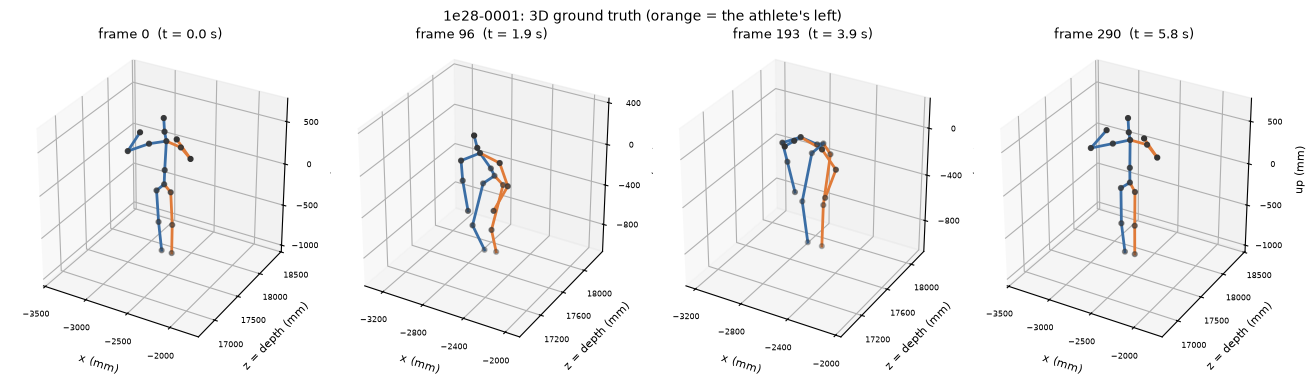

In [9]:
# Which landmarks to connect with a line. This is anatomy, not data: the file stores
# points only, and any skeleton drawing needs a list like this supplied by hand.
BONES = [
    ("head_top", "head"), ("head", "neck"), ("neck", "spine"), ("spine", "pelvis"),
    ("neck", "left_shoulder"), ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),
    ("neck", "right_shoulder"), ("right_shoulder", "right_elbow"), ("right_elbow", "right_wrist"),
    ("pelvis", "left_hip"), ("left_hip", "left_knee"), ("left_knee", "left_ankle"),
    ("pelvis", "right_hip"), ("right_hip", "right_knee"), ("right_knee", "right_ankle"),
]


def draw_pose_3d(axes, joints, title=""):
    """Draw one frame's 17 landmarks as a stick figure.

    ASPset's +y points DOWN, while a matplotlib 3D plot draws its third coordinate
    upwards. So we plot (x, z, -y): negating y turns the body the right way up, and
    using z as the horizontal depth axis keeps the figure right-handed rather than
    mirrored (a plain axis swap would silently exchange the athlete's left and right).
    """
    plotted = np.stack([joints[:, 0], joints[:, 2], -joints[:, 1]], axis=-1)

    for start, end in BONES:
        pair = plotted[[JOINT_NAMES.index(start), JOINT_NAMES.index(end)]]
        # Colour by side so a left/right mix-up would be visible immediately.
        colour = "#e07b39" if start.startswith("left") or end.startswith("left") else "#3b6ea5"
        axes.plot(*pair.T, color=colour, linewidth=2)

    axes.scatter(*plotted.T, s=12, color="#333333")
    axes.set_box_aspect((1, 1, 1))
    axes.set_xlabel("x (mm)", fontsize=8)
    axes.set_ylabel("z = depth (mm)", fontsize=8)
    axes.set_zlabel("up (mm)", fontsize=8)
    axes.tick_params(labelsize=6)
    for axis in (axes.xaxis, axes.yaxis, axes.zaxis):
        axis.set_major_locator(plt.MaxNLocator(4))
    axes.set_title(title, fontsize=9)

    # Equal scaling on every axis, otherwise the body looks stretched.
    centre = 0.5 * (plotted.min(0) + plotted.max(0))
    reach = 0.5 * float((plotted.max(0) - plotted.min(0)).max()) + 100
    axes.set_xlim(centre[0] - reach, centre[0] + reach)
    axes.set_ylim(centre[1] - reach, centre[1] + reach)
    axes.set_zlim(centre[2] - reach, centre[2] + reach)


# Four moments spread across the clip, to see the movement.
sample_frames = np.linspace(0, len(joints_mm) - 1, 4).astype(int)

figure = plt.figure(figsize=(13, 3.6))
for panel, frame in enumerate(sample_frames):
    axes = figure.add_subplot(1, 4, panel + 1, projection="3d")
    draw_pose_3d(axes, joints_mm[frame], title=f"frame {frame}  (t = {frame/50:.1f} s)")
plt.suptitle(f"{SUBJECT}-{CLIP}: 3D ground truth (orange = the athlete's left)", fontsize=10)
plt.tight_layout()
plt.show()

---
## Part 4 — The cameras

We have 3D points in a world frame, and a video. The **camera calibration** is what connects them:
it tells you which pixel a given 3D point lands on. That relationship is the reason this dataset
is useful for training pose estimators at all.

Each calibration file holds two matrices, stored flat:

* the **extrinsic** matrix, 4×4 — *where the camera is*: it moves a point from the world frame
  into the camera's own frame;
* the **intrinsic** matrix, 3×4 — *what the lens does*: it turns a camera-frame point into pixels.

In [10]:
def load_camera(path):
    """Read a camera calibration file.

    Both matrices are stored as flat lists of numbers, so they need reshaping.

    Returns:
        intrinsic: (3, 4) — camera frame to pixels.
        extrinsic: (4, 4) — world frame to camera frame.
    """
    with open(path) as handle:
        data = json.load(handle)
    intrinsic = np.array(data["intrinsic_matrix"]).reshape(3, 4)
    extrinsic = np.array(data["extrinsic_matrix"]).reshape(4, 4)
    return intrinsic, extrinsic


intrinsic, extrinsic = load_camera(FILES["camera"])

print(f"the {VIEW} camera of subject {SUBJECT}\n")
print("intrinsic (3x4):")
print(intrinsic)
print(f"   focal length {intrinsic[0, 0]:.0f} px, principal point "
      f"({intrinsic[0, 2]:.0f}, {intrinsic[1, 2]:.0f}) px -- the middle of a 3840x2160 frame")
print("\nextrinsic (4x4), world -> camera:")
print(extrinsic)

the left camera of subject 1e28

intrinsic (3x4):
[[4036.16    0.   1913.41    0.  ]
 [   0.   3994.25 1097.92    0.  ]
 [   0.      0.      1.      0.  ]]
   focal length 4036 px, principal point (1913, 1098) px -- the middle of a 3840x2160 frame

extrinsic (4x4), world -> camera:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


### Where the three cameras stand

The extrinsic matrix contains a rotation (top-left 3×3) and a translation. Inverting it gives the
camera's own position in the world, which is the easiest way to picture the rig.

In [11]:
def camera_position(extrinsic):
    """Where the camera sits, in world coordinates (mm).

    The extrinsic maps world -> camera as `x_cam = R @ x_world + t`. The camera itself is
    at x_cam = 0, so solving for x_world gives `-R.T @ t`.
    """
    rotation, translation = extrinsic[:3, :3], extrinsic[:3, 3]
    return -rotation.T @ translation


print("camera positions in the world frame (mm):\n")
positions = {}
for view in ["left", "mid", "right"]:
    _, view_extrinsic = load_camera(CAMERA_DIR / SUBJECT / f"{SUBJECT}-{view}.json")
    positions[view] = camera_position(view_extrinsic)
    print(f"  {view:<6} {positions[view]}")

print("\n  -> the LEFT camera is at the origin: the world frame IS the left camera's frame.")
print(f"\nspacing between the cameras:")
print(f"  left  to mid    {np.linalg.norm(positions['mid'] - positions['left'])/1000:.2f} m")
print(f"  mid   to right  {np.linalg.norm(positions['right'] - positions['mid'])/1000:.2f} m")
print(f"  left  to right  {np.linalg.norm(positions['right'] - positions['left'])/1000:.2f} m")

distance = np.linalg.norm(joints_mm[:, JOINT_NAMES.index("pelvis")] - positions[VIEW], axis=1)
print(f"\nthe athlete is {distance.min()/1000:.1f}-{distance.max()/1000:.1f} m from the {VIEW} camera")

camera positions in the world frame (mm):

  left   [0. 0. 0.]
  mid    [9840.68   65.37 1761.68]
  right  [14346.59   -77.85 10543.59]

  -> the LEFT camera is at the origin: the world frame IS the left camera's frame.

spacing between the cameras:
  left  to mid    10.00 m
  mid   to right  9.87 m
  left  to right  17.80 m

the athlete is 17.9-18.2 m from the left camera


### Projecting 3D onto the image

This is the step that ties the whole dataset together, and it is three lines:

1. move the point into the camera's frame with the extrinsic matrix;
2. multiply by the intrinsic matrix;
3. **divide by depth** — this is the perspective step, and it is what makes distant things small.

In [12]:
def project_to_pixels(points_mm, intrinsic, extrinsic):
    """Project 3D world points onto the image plane.

    Args:
        points_mm: (N, 3) world positions in mm.
        intrinsic: (3, 4) matrix.
        extrinsic: (4, 4) matrix.

    Returns:
        (N, 2) pixel coordinates, with (0, 0) at the top-left of the frame.
    """
    # 1. world -> camera. Append a 1 to each point so the 4x4 can apply its translation.
    homogeneous = np.hstack([points_mm, np.ones((len(points_mm), 1))])
    in_camera = homogeneous @ extrinsic.T                    # (N, 4)

    # 2. camera -> image, still with an unresolved depth factor.
    projected = in_camera @ intrinsic.T                      # (N, 3) = (u*z, v*z, z)

    # 3. divide by depth. THIS is perspective: a point twice as far away lands
    #    half as far from the image centre.
    return projected[:, :2] / projected[:, 2:3]


FRAME = len(joints_mm) // 2                  # a frame in the middle of the clip
pixels = project_to_pixels(joints_mm[FRAME], intrinsic, extrinsic)

print(f"frame {FRAME}: the 17 landmarks as pixel coordinates\n")
for name, (u, v) in zip(JOINT_NAMES, pixels):
    print(f"  {name:<16} ({u:7.1f}, {v:7.1f})")

frame 145: the 17 landmarks as pixel coordinates

  right_ankle      ( 1298.0,  1314.0)
  right_knee       ( 1291.6,  1229.8)
  right_hip        ( 1296.5,  1146.8)
  right_wrist      ( 1286.8,  1299.2)
  right_elbow      ( 1278.5,  1238.3)
  right_shoulder   ( 1272.9,  1175.4)
  left_ankle       ( 1322.8,  1319.0)
  left_knee        ( 1328.9,  1230.7)
  left_hip         ( 1333.5,  1147.5)
  left_wrist       ( 1330.9,  1298.9)
  left_elbow       ( 1336.3,  1241.4)
  left_shoulder    ( 1339.9,  1179.5)
  head_top         ( 1303.4,  1173.7)
  head             ( 1303.0,  1164.9)
  neck             ( 1303.1,  1156.1)
  spine            ( 1315.6,  1120.3)
  pelvis           ( 1316.6,  1132.2)


Do those pixel coordinates actually land on the athlete? Drawing them over the real video frame is
the only honest way to check — and it verifies the joints, the calibration, and the
frame-numbering all at once.

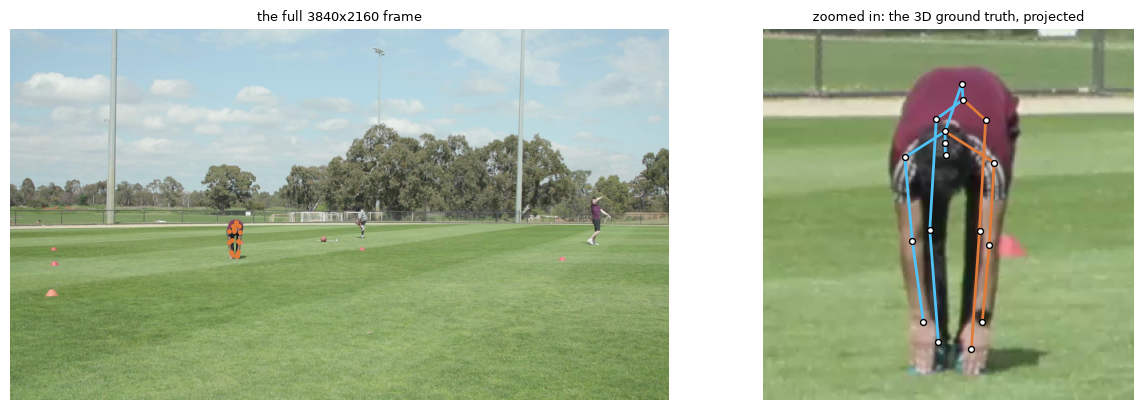

In [13]:
def read_frame(path, frame_number):
    """Decode one frame of a video as an RGB image.

    Args:
        path: path to the video.
        frame_number: 0-based frame index.

    Returns:
        An (H, W, 3) uint8 RGB array.
    """
    capture = cv2.VideoCapture(str(path))
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_number)      # seek
    success, image = capture.read()
    capture.release()
    if not success:
        raise RuntimeError(f"could not read frame {frame_number} of {path.name}")
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)           # OpenCV decodes as BGR


image = read_frame(FILES["video"], FRAME)

figure, panels = plt.subplots(1, 2, figsize=(13, 4.2))

# Left: the whole 4K frame, with the projected joints marked.
panels[0].imshow(image)
panels[0].scatter(*pixels.T, s=6, color="#e07b39")
panels[0].set_title(f"the full {image.shape[1]}x{image.shape[0]} frame", fontsize=9)
panels[0].axis("off")

# Right: a crop around the athlete, so you can actually see the overlay.
# Centre the crop on the middle of the joints' bounding box (not their mean, which is
# pulled around by wherever the limbs happen to be) and leave a 40% margin.
centre = 0.5 * (pixels.min(0) + pixels.max(0))
half = 0.7 * max(pixels.max(0) - pixels.min(0))
left, top = (centre - half).astype(int)
right, bottom = (centre + half).astype(int)

panels[1].imshow(image[top:bottom, left:right])
for start, end in BONES:
    pair = pixels[[JOINT_NAMES.index(start), JOINT_NAMES.index(end)]] - [left, top]
    colour = "#e07b39" if start.startswith("left") or end.startswith("left") else "#4fc3f7"
    panels[1].plot(*pair.T, color=colour, linewidth=2)
panels[1].scatter(*(pixels - [left, top]).T, s=18, color="white", edgecolor="black", zorder=5)
panels[1].set_title("zoomed in: the 3D ground truth, projected", fontsize=9)
panels[1].axis("off")

plt.tight_layout()
plt.show()

The skeleton lands on the athlete. That single picture confirms a lot at once: the calibration is
right, our projection maths is right, and **frame *i* of the video corresponds to frame *i* of the
`.c3d` file** — there is no time offset to correct for.

(In this particular frame the athlete is bent forward, which is why the head landmarks printed
above sit *lower* in the image than the hips. Worth checking against the picture before assuming
something is broken — real sports data is full of poses like this.)

---
## Part 5 — The bounding boxes

Each clip has a `.csv` of bounding boxes, one row per frame. The header tells you the format:
`x1,y1,x2,y2`, i.e. the top-left and bottom-right corners in pixels.

In [14]:
def load_boxes(path):
    """Read a bounding-box CSV as an (frames, 4) array of x1, y1, x2, y2 in pixels."""
    return np.loadtxt(path, delimiter=",", skiprows=1)      # skip the header row


boxes = load_boxes(FILES["box"])

print("boxes:", boxes.shape, " = (frames, [x1, y1, x2, y2])")
print("first 3 rows:\n", boxes[:3])
print(f"\nframes: video {len(joints_mm)}, boxes {len(boxes)} -- they match, one row per frame")

boxes: (291, 4)  = (frames, [x1, y1, x2, y2])
first 3 rows:
 [[1233.52  946.29 1392.59 1318.39]
 [1235.82  946.34 1391.35 1318.45]
 [1237.89  946.6  1390.1  1318.51]]

frames: video 291, boxes 291 -- they match, one row per frame


### Where do these boxes come from?

This matters more than it looks. If the boxes were produced by a *person detector*, you could use
them at inference time. If instead they were computed from the ground-truth joints, then using
them at inference leaks the answer into your input, and your accuracy numbers will be optimistic.

We can settle it: project the 17 joints ourselves and see whether their tight bounding box
reproduces the file.

In [15]:
# Project every frame's joints and take the tight box around them.
our_boxes = []
for frame_joints in joints_mm:
    frame_pixels = project_to_pixels(frame_joints, intrinsic, extrinsic)
    our_boxes.append([*frame_pixels.min(0), *frame_pixels.max(0)])
our_boxes = np.array(our_boxes)

difference = np.abs(our_boxes - boxes).max()
print(f"largest disagreement over all {len(boxes)} frames: {difference:.3f} px")
print("\n-> the boxes ARE the tight bounding box of the projected ground-truth joints.")
print("   They are derived from the answer, not detected from the image. Do not feed them")
print("   to a model at inference time and call the result detection-free.")

largest disagreement over all 291 frames: 0.005 px

-> the boxes ARE the tight bounding box of the projected ground-truth joints.
   They are derived from the answer, not detected from the image. Do not feed them
   to a model at inference time and call the result detection-free.


### How big is the athlete in the frame?

Worth knowing before you design anything: these are 4K frames of a subject standing ~18 m away.

In [16]:
box_widths = boxes[:, 2] - boxes[:, 0]
box_heights = boxes[:, 3] - boxes[:, 1]

frame_height, frame_width = image.shape[:2]
height_fraction = box_heights.mean() / frame_height
area_fraction = (box_widths * box_heights).mean() / (frame_width * frame_height)

print(f"average box  {box_widths.mean():.0f} x {box_heights.mean():.0f} px")
print(f"the athlete fills {100*height_fraction:.1f}% of the frame height")
print(f"                 {100*area_fraction:.2f}% of the frame area")
print("\n-> over 99% of every 4K frame is grass. Any model here must crop to the")
print("   subject first; feeding it whole frames wastes almost all the computation.")

average box  117 x 317 px
the athlete fills 14.7% of the frame height
                 0.47% of the frame area

-> over 99% of every 4K frame is grass. Any model here must crop to the
   subject first; feeding it whole frames wastes almost all the computation.


---
## Part 6 — Dataset-wide statistics

So far, one clip. Loading the 3D joints for all 60 clips is quick (they are small files), and it
tells us what the dataset looks like as a whole.

In [17]:
# Load every clip's 3D joints once. Only the joints -- the videos stay on disk.
all_clips = {}
for subject, clip, view in clips:
    path = JOINTS_DIR / subject / f"{subject}-{clip}.c3d"
    joints, _ = load_joints_3d(path)
    all_clips[(subject, clip)] = joints

lengths = np.array([len(j) for j in all_clips.values()])
print(f"loaded {len(all_clips)} clips, {lengths.sum():,} frames total "
      f"({lengths.sum()/50/60:.1f} minutes at 50 fps)")

loaded 60 clips, 13,708 frames total (4.6 minutes at 50 fps)


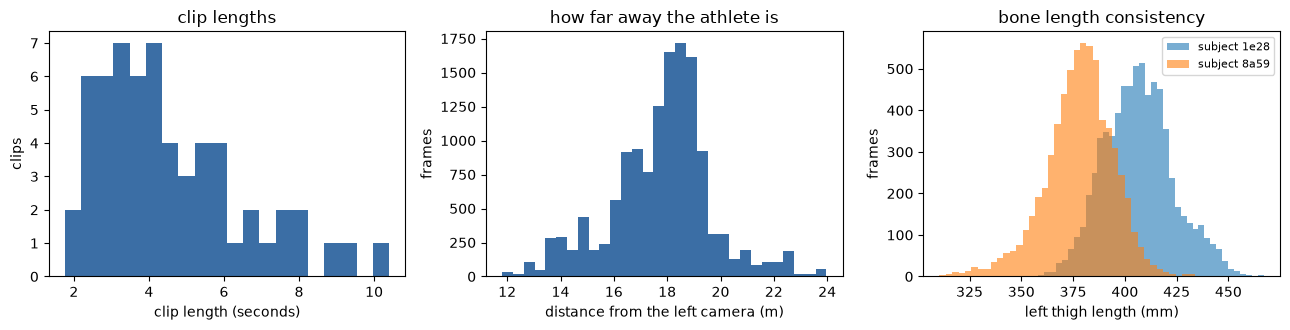

In [18]:
def bone_length(joints, start, end):
    """Length of one bone, per frame, in mm."""
    a = joints[:, JOINT_NAMES.index(start)]
    b = joints[:, JOINT_NAMES.index(end)]
    return np.linalg.norm(a - b, axis=1)


figure, panels = plt.subplots(1, 3, figsize=(13, 3.4))

# 1. how long the clips are
panels[0].hist(lengths / 50, bins=20, color="#3b6ea5")
panels[0].set(xlabel="clip length (seconds)", ylabel="clips", title="clip lengths")

# 2. how far the athlete is from the world origin (= the left camera)
distances = np.concatenate([np.linalg.norm(j[:, JOINT_NAMES.index("pelvis")], axis=1)
                            for j in all_clips.values()]) / 1000
panels[1].hist(distances, bins=30, color="#3b6ea5")
panels[1].set(xlabel="distance from the left camera (m)", ylabel="frames",
              title="how far away the athlete is")

# 3. is a bone the same length all the way through? It should be -- bones are rigid.
for subject in subjects:
    thighs = np.concatenate([bone_length(j, "left_hip", "left_knee")
                             for (s, _), j in all_clips.items() if s == subject])
    panels[2].hist(thighs, bins=40, alpha=0.6, label=f"subject {subject}")
panels[2].set(xlabel="left thigh length (mm)", ylabel="frames", title="bone length consistency")
panels[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

The third panel is a data-quality check, and it is worth understanding. A thigh bone is rigid, so
its measured length should be a single number. Instead it is a spread of a few percent, and the
two subjects sit at clearly different values.

The spread tells you these landmarks are **markers on the skin**, not true anatomical joint
centres: skin slides over bone as the athlete moves. The separation tells you the two athletes are
different sizes — which is correct, but also a reminder that **two subjects is an evaluation set,
not a training set**. A model trained on two bodies has seen almost no body-shape variation.

In [19]:
print(f"{'bone':<30}{'mean (mm)':>12}{'variation':>12}")
for start, end in [("left_hip", "left_knee"), ("left_knee", "left_ankle"),
                   ("left_shoulder", "left_elbow"), ("left_elbow", "left_wrist"),
                   ("neck", "head_top")]:
    values = np.concatenate([bone_length(j, start, end) for j in all_clips.values()])
    # Coefficient of variation: the spread as a percentage of the mean.
    print(f"{start + ' - ' + end:<30}{values.mean():>12.0f}{100*values.std()/values.mean():>11.1f}%")

bone                             mean (mm)   variation


left_hip - left_knee                   393        5.6%
left_knee - left_ankle                 399        4.4%
left_shoulder - left_elbow             274        6.4%
left_elbow - left_wrist                234        8.6%
neck - head_top                        239        9.8%


---
## Part 7 — Summary

**What ASPset-510 is.** Outdoor sports video with synchronised 3D pose ground truth. Athletes are
filmed by three fixed, calibrated 4K cameras; the 3D joints come from a separate motion-capture
system and live in a world frame shared by all the cameras.

**What is in this copy.**

| | |
|---|---|
| split | `train` only |
| subjects | 2 (`1e28`, `8a59`) |
| clips | 60, of 4–10 seconds |
| frames | 13 708 (≈4.6 minutes at 50 fps) |
| video | 3840×2160, one `.mkv` per clip |
| ground truth | 17 landmarks per frame, in millimetres |
| on disk | 1.3 GB |

**Conventions, all verified above.**

* 3D joints are in **millimetres**, with **+y pointing down**.
* The **world frame is the left camera's frame** (its extrinsic matrix is the identity).
* Projection is `pixels = K · (E · X)`, then divide by depth. No lens distortion is modelled.
* Frame *i* of the video is frame *i* of the `.c3d` and row *i* of the box CSV. No offset.

**Four things to be careful about.**

1. **One camera view per clip.** No clip can be triangulated from this download.
2. **The boxes are ground truth in disguise** — the tight box of the projected joints, matching to
   0.006 px. Using them at inference leaks the answer.
3. **Two subjects only.** Fine for evaluation, far too little body-shape variety for training.
4. **The landmarks are skin markers**, so expect a few centimetres of systematic disagreement with
   any anatomical joint centre — including a fitted rig's.

### Using this with MHR

MHR works in **centimetres with +y up**; ASPset is **millimetres with +y down**. Converting
between them is one line, and it must not mirror the body:

```python
joints_mhr_cm = 0.1 * joints_aspset_mm * np.array([1.0, -1.0, -1.0])
```

Flipping *two* axes keeps the coordinate frame right-handed. Flipping only y would turn the
athlete's left side into their right — a mistake that produces a body that still looks like a
body, so it will not announce itself.

16 of the 17 landmarks have a matching MHR joint (`head_top` does not — MHR has no joint at the
crown of the skull). See `demos ipynb/mhr_kinematics.ipynb` for MHR's skeleton and joint naming,
and `mhr_posing/analytic_ik.py` for turning 3D landmarks like these into an MHR pose.